# Single tx dataset

In [21]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from types import SimpleNamespace

from cli import Cli
from dataset_generator.types import DATASET_TYPE

# Define the absolute path for the root directory for outputs here (and if possible, make sure to have a prepared _dataset folder)
OUTPUTS_ROOT = Path("/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/mlpbased-single-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge")

## Test runs

The next cells will run the model training for different metapath difference thresholds.

This process can take a long time to finish.

**If you already have the models trained, you can skip this section and go to the evaluation section.**

In [12]:
dataset_path = OUTPUTS_ROOT.absolute() / "_dataset"
fixed_args = {
    "device": "cpu",  # Change to "cuda" if you have a GPU and want to use it
    "dataset": DATASET_TYPE.SINGLE,
    "load_data": str(dataset_path),
    "new_dataset": None,
    "force_reload": False,
    "num_workers": 0,
    "tags": "mlpbased,ablationsemfusion",

    "num_epochs": 100,
    "learning_rate": 0.005,
    "augment_factor": 0,
    "dme_threshold": 0.5,
    "early_stopping": 15,
    "kfolds": 5,
    "first_layer_channels": 128,
    "hidden_channels": 64,
    "dropout": 0.5,
    "input_drop": 0.0,
    "att_drop": 0.0,
    "n_fp_layers": 2,
    "n_mlp_layers": 2,
    "activation": "relu",
    "pooling": "mean",
    "residual": False,
    "random_seed": 42,
    "test_split": 0.15,
    "rep_dim": 64,
    "eta": 1.0,
    "deep_sad_eps": 1.0,
    "grad_clip": 1.0,
    "weight_decay": 1e-6,
    "ae_pretrain": False,
}

In [13]:
# Run with semantic fusion
Cli.train_model(SimpleNamespace(
    **fixed_args,
    rm_semantic_fusion=False
))

Early stopping: 15
Exporting data from database to CSV files... 


Processing single-chain graphs dataset: 100%|██████████| 1152/1152 [00:14<00:00, 79.57graph/s]


Splitting dataset into train/val/test sets with test size 15% and 5 folds for cross-validation.
Normalizing node features using min-max normalization.
Label distribution in train/val pool: 782 normal, 197 anomaly.
Identified 264 differential meta-paths for training.
Fold 1: centre initialised from 625 normal graphs.
Fold 1/5, epoch 1/100 — training...
  Fold 1, epoch 1, train loss: 1.5176, val loss: 0.1747, PR-AUC (anomaly): 0.7555, f2-score (anomaly): 0.8373, tau: 1.2513e-01
  dist(normal) 1.0167e-01+-1.7177e-01 | dist(anomaly) 5.2253e+01+-8.4283e+01
              precision    recall  f1-score   support

           0       0.97      0.89      0.93       157
           1       0.66      0.90      0.76        39

    accuracy                           0.89       196
   macro avg       0.82      0.89      0.84       196
weighted avg       0.91      0.89      0.89       196

Fold 1/5, epoch 2/100 — training...
  Fold 1, epoch 2, train loss: 0.3731, val loss: 0.1792, PR-AUC (anomaly): 0.52

'/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/mlpbased-single-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_es15_mlpbased_ablationsemfusion__202608171517'

In [14]:
# Run without semantic fusion
Cli.train_model(SimpleNamespace(
    **fixed_args,
    rm_semantic_fusion=True
))

Early stopping: 15
Exporting data from database to CSV files... 
Splitting dataset into train/val/test sets with test size 15% and 5 folds for cross-validation.
Normalizing node features using min-max normalization.
Label distribution in train/val pool: 782 normal, 197 anomaly.
Identified 264 differential meta-paths for training.
Fold 1: centre initialised from 625 normal graphs.
Fold 1/5, epoch 1/100 — training...
  Fold 1, epoch 1, train loss: 2.5064, val loss: 0.2811, PR-AUC (anomaly): 0.7621, f2-score (anomaly): 0.8374, tau: 4.1361e-01
  dist(normal) 2.5503e-01+-4.4121e-01 | dist(anomaly) 6.1730e+01+-1.1006e+02
              precision    recall  f1-score   support

           0       0.97      0.92      0.94       157
           1       0.72      0.87      0.79        39

    accuracy                           0.91       196
   macro avg       0.84      0.89      0.87       196
weighted avg       0.92      0.91      0.91       196

Fold 1/5, epoch 2/100 — training...
  Fold 1, epoc

'/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/mlpbased-single-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_nosf_es15_mlpbased_ablationsemfusion__202608171525'

## Results processing

In [22]:
# Obtain all relevant run directories that match the pattern and contain a params.yaml file
run_dirs = sorted(
    p for p in OUTPUTS_ROOT.glob("train_epochs100_augment0_lr0.005*")
    if p.is_dir() and (p / "params.yaml").exists()
)

print(f"Found {len(run_dirs)} run directories")
for p in run_dirs:
    print(p)

Found 2 run directories
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/mlpbased-single-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_es15_mlpbased_ablationsemfusion__202608171517
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/mlpbased-single-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_nosf_es15_mlpbased_ablationsemfusion__202608171525


In [23]:
import yaml
import pandas as pd

def load_run_config(run_dir: Path) -> dict:
    TOTAL_METAPATHS = 6475  # Total number of metapaths in the dataset
    with open(run_dir / "params.yaml") as f:
        doc = yaml.safe_load(f)

    return {
        "run_dir": run_dir,
        "run_name": run_dir.name,
        "rm_semantic_fusion": doc["params"].get("rm_semantic_fusion", False),
        "reported_metapaths": doc["dme"]["reported_metapaths"],
        "pct_metapaths": doc["dme"]["reported_metapaths"] / TOTAL_METAPATHS,
        "total_samples": doc["dataset"]["stats"]["total_samples"],
        "anomaly_ratio": doc["dataset"]["stats"]["anomaly_ratio"],
    }

def load_test_metrics(run_dir: Path) -> dict:
    df = pd.read_csv(run_dir / "test_metrics.csv")
    metric_cols = [c for c in df.columns if c != "fold"]

    result = {"run_dir": run_dir}
    for col in metric_cols:
        result[f"{col}_mean"] = df[col].mean()
        result[f"{col}_std"] = df[col].std(ddof=0)
    
    result["precision_macro_mean"] = ((df["precision_normal"] + df["precision_anomaly"]) / 2).mean()
    result["precision_macro_std"] = ((df["precision_normal"] + df["precision_anomaly"]) / 2).std(ddof=0)
    result["recall_macro_mean"] = ((df["recall_normal"] + df["recall_anomaly"]) / 2).mean()
    result["recall_macro_std"] = ((df["recall_normal"] + df["recall_anomaly"]) / 2).std(ddof=0)
    result["f1_macro_mean"] = ((df["f1_normal"] + df["f1_anomaly"]) / 2).mean()
    result["f1_macro_std"] = ((df["f1_normal"] + df["f1_anomaly"]) / 2).std(ddof=0)
    return result

def load_fold_durations(run_dir: Path) -> dict:
    df = pd.read_csv(run_dir / "fold_durations.csv")
    return {
        "run_dir": run_dir,
        "fold_time_mean": df["time"].mean(),
        "fold_time_std": df["time"].std(ddof=0),  # match summary.txt convention
        "fold_time_total": df["time"].sum(),
    }


configs = [load_run_config(p) for p in run_dirs]
configs_df = pd.DataFrame(configs)

metrics = [load_test_metrics(p) for p in run_dirs]
metrics_df = pd.DataFrame(metrics)

durations = [load_fold_durations(p) for p in run_dirs]
durations_df = pd.DataFrame(durations)

comparison_df = (
    configs_df
    .merge(metrics_df, on="run_dir")
    .merge(durations_df, on="run_dir")
    .sort_values(["rm_semantic_fusion"])
    .reset_index(drop=True)
)
comparison_df

,run_dir,run_name,rm_semantic_fusion,reported_metapaths,pct_metapaths,total_samples,anomaly_ratio,test_loss_mean,test_loss_std,accuracy_mean,...,threshold_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,fold_time_mean,fold_time_std,fold_time_total
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_es15_mlpbased...,False,264,0.040772,1152,0.2014,17.088407,15.426660,0.938728,...,0.052767,0.897048,0.028357,0.918944,0.050721,0.906587,0.037653,90.038,13.315360,450.19
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_nosf_es15_mlp...,True,264,0.040772,1152,0.2014,5.839429,6.193234,0.936416,...,1.048105,0.889077,0.027411,0.940952,0.038652,0.908343,0.028366,70.396,24.184964,351.98


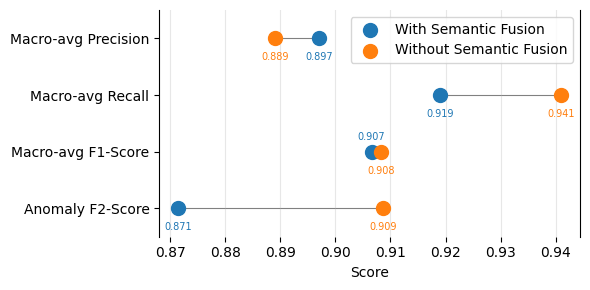

In [ ]:
import numpy as np

# Cleveland dot plot: metrics on y, score on x; one colored dot per evaluation
import matplotlib.pyplot as plt

plot_df = comparison_df.copy()
plot_df["evaluation"] = plot_df["rm_semantic_fusion"].map({False: "With Semantic Fusion", True: "Without Semantic Fusion"})
evals = plot_df["evaluation"].tolist()
metric_cols = [
    "precision_macro_mean",
    "recall_macro_mean",
    "f1_macro_mean",
    "f2_anomaly_mean"
]
y = np.arange(len(metric_cols))
labels = [
    "Macro-avg Precision",
    "Macro-avg Recall",
    "Macro-avg F1-Score",
    "Anomaly F2-Score"
]

fig, ax = plt.subplots(figsize=(6, 3))

# map evaluations to distinct colors
unique_evals = plot_df["evaluation"].unique().tolist()
cmap = plt.get_cmap("tab10")
color_map = {ev: cmap(i) for i, ev in enumerate(unique_evals)}

# draw grey connector lines for each metric
for i in range(len(metric_cols)):
    vals = plot_df[metric_cols].iloc[:, i] if False else plot_df[metric_cols].iloc[:, i]  # noop for clarity
for i in range(len(metric_cols)):
    # values for this metric across evaluations (respect row order)
    vals = plot_df[metric_cols].iloc[:, i].to_numpy()  # not used; keep loop for connector below

# connector and points (use the row order in plot_df)
for i, metric in enumerate(metric_cols):
    vals = plot_df[metric].to_numpy(dtype=float)
    ax.plot(vals, [i, i], color="gray", linewidth=0.8, zorder=1)
for j, ev_name in enumerate(evals):
    row = plot_df.loc[plot_df["evaluation"] == ev_name, metric_cols].iloc[0]
    for i, metric in enumerate(metric_cols):
        ax.annotate(
            f"{row[metric]:.3f}",
            (row[metric], i),
            textcoords="offset points",
            xytext=(0, 14) if j == 0 and abs(plot_df[metric].iloc[0] - plot_df[metric].iloc[1]) < 0.004 else (0, -10),
            ha="center",
            va="top",
            fontsize=7,
            color=color_map[ev_name],
        )
    vals = plot_df.loc[plot_df["evaluation"] == ev_name, metric_cols].iloc[0].to_numpy(dtype=float)
    ax.scatter(vals, y, s=100, color=color_map[ev_name], label=ev_name, zorder=2)

ax.set_yticks(y)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_ylim(y.min() - 0.5, y.max() + 0.5)

ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("Score")
ax.grid(axis="x", alpha=0.3)
# set x limits with a small margin
all_vals = plot_df[metric_cols].to_numpy(dtype=float)
xmin, xmax = all_vals.min(), all_vals.max()
pad = (xmax - xmin) * 0.05 if xmax > xmin else 0.01
ax.set_xlim(xmin - pad, xmax + pad)
ax.legend()
plt.tight_layout()

plt.show()

In [18]:
trimmed_df = comparison_df[[
    "rm_semantic_fusion",
    "accuracy_mean",
    "accuracy_std",
    "precision_normal_mean",
    "precision_normal_std",
    "recall_normal_mean",
    "recall_normal_std",
    "f1_normal_mean",
    "f1_normal_std",
    "precision_anomaly_mean",
    "precision_anomaly_std",
    "recall_anomaly_mean",
    "recall_anomaly_std",
    "f1_anomaly_mean",
    "f1_anomaly_std",
    "f2_anomaly_mean",
    "f2_anomaly_std",
    "pr_auc_mean",
    "pr_auc_std",
    "fold_time_mean",
    "fold_time_std",
]]
trimmed_df

,rm_semantic_fusion,accuracy_mean,accuracy_std,precision_normal_mean,precision_normal_std,recall_normal_mean,recall_normal_std,f1_normal_mean,f1_normal_std,precision_anomaly_mean,...,recall_anomaly_mean,recall_anomaly_std,f1_anomaly_mean,f1_anomaly_std,f2_anomaly_mean,f2_anomaly_std,pr_auc_mean,pr_auc_std,fold_time_mean,fold_time_std
0,False,0.938728,0.023579,0.970978,0.024638,0.952174,0.008696,0.961360,0.014619,0.823118,...,0.885714,0.097311,0.851814,0.060735,0.871456,0.081669,0.864744,0.038643,90.038,13.315360
1,True,0.936416,0.020680,0.987126,0.022130,0.933333,0.029842,0.958916,0.013947,0.791028,...,0.948571,0.089260,0.857770,0.043791,0.908607,0.064141,0.853519,0.074475,70.396,24.184964


In [19]:
PCT_SCALE_EXCLUDE = {"fold_time"}  # keep seconds as seconds, not *100

def format_stat(mean, std, base):
    scale = 1 if base in PCT_SCALE_EXCLUDE else 100
    return f"{mean * scale:.2f} \u00b1 {std * scale:05.2f}"

metric_bases = [c[:-5] for c in trimmed_df.columns if c.endswith("_mean")]

display_df = pd.DataFrame(index=trimmed_df.index)
for base in metric_bases:
    display_df[base] = trimmed_df.apply(
        lambda row: format_stat(row[f"{base}_mean"], row[f"{base}_std"], base), axis=1
    )

display_df.insert(0, "Semantic Fusion", (trimmed_df["rm_semantic_fusion"].map({False: "Included", True: "Not Included"})))
display_df = display_df.set_index("Semantic Fusion")

final_table = display_df.T
final_table

Semantic Fusion,Included,Not Included
accuracy,93.87 ± 02.36,93.64 ± 02.07
precision_normal,97.10 ± 02.46,98.71 ± 02.21
recall_normal,95.22 ± 00.87,93.33 ± 02.98
f1_normal,96.14 ± 01.46,95.89 ± 01.39
precision_anomaly,82.31 ± 03.58,79.10 ± 06.14
recall_anomaly,88.57 ± 09.73,94.86 ± 08.93
f1_anomaly,85.18 ± 06.07,85.78 ± 04.38
f2_anomaly,87.15 ± 08.17,90.86 ± 06.41
pr_auc,86.47 ± 03.86,85.35 ± 07.45
fold_time,90.04 ± 13.32,70.40 ± 24.18


In [20]:
# Turn the unicode ± into LaTeX math syntax, and escape underscores in row labels
import re

METRIC_LABELS = {
    "Semantic Fusion": "Semantic Fusion",
    "accuracy": "Accuracy (\\%)",
    "precision_normal": "Precision (Normal) (\\%)",
    "recall_normal": "Recall (Normal) (\\%)",
    "f1_normal": "F1 (Normal) (\\%)",
    "precision_anomaly": "Precision (Anomaly) (\\%)",
    "recall_anomaly": "Recall (Anomaly) (\\%)",
    "f1_anomaly": "F1 (Anomaly) (\\%)",
    "f2_anomaly": "F2 (Anomaly) (\\%)",
    "pr_auc": "PR-AUC (\\%)",
    "fold_time": "Fold Training Time (sec/fold)",
}

def to_math_pm(s: str) -> str:
    return re.sub(r"(-?[\d.]+) \u00b1 (-?[\d.]+)", r"$\1 \\pm \2$", s)

latex_ready = final_table.map(to_math_pm)
latex_ready = latex_ready.rename(index=METRIC_LABELS)
latex_ready.index = latex_ready.index.str.replace("_", r"\_", regex=False)

latex_str = latex_ready.to_latex(
    escape=False,  # cell values already contain LaTeX ($\pm$), don't double-escape
    column_format="l" + "c" * len(latex_ready.columns),
    caption="Effect of the DME threshold on test-set performance",
    label="tab:ablation_semantic_fusion",
)
print(latex_str)


\begin{table}
\caption{Effect of the DME threshold on test-set performance}
\label{tab:ablation_semantic_fusion}
\begin{tabular}{lcc}
\toprule
Semantic Fusion & Included & Not Included \\
\midrule
Accuracy (\%) & $93.87 \pm 02.36$ & $93.64 \pm 02.07$ \\
Precision (Normal) (\%) & $97.10 \pm 02.46$ & $98.71 \pm 02.21$ \\
Recall (Normal) (\%) & $95.22 \pm 00.87$ & $93.33 \pm 02.98$ \\
F1 (Normal) (\%) & $96.14 \pm 01.46$ & $95.89 \pm 01.39$ \\
Precision (Anomaly) (\%) & $82.31 \pm 03.58$ & $79.10 \pm 06.14$ \\
Recall (Anomaly) (\%) & $88.57 \pm 09.73$ & $94.86 \pm 08.93$ \\
F1 (Anomaly) (\%) & $85.18 \pm 06.07$ & $85.78 \pm 04.38$ \\
F2 (Anomaly) (\%) & $87.15 \pm 08.17$ & $90.86 \pm 06.41$ \\
PR-AUC (\%) & $86.47 \pm 03.86$ & $85.35 \pm 07.45$ \\
Fold Training Time (sec/fold) & $90.04 \pm 13.32$ & $70.40 \pm 24.18$ \\
\bottomrule
\end{tabular}
\end{table}



# Cross-chain tx scope

In [26]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from types import SimpleNamespace

from cli import Cli
from dataset_generator.types import DATASET_TYPE

# Define the absolute path for the root directory for outputs here (and if possible, make sure to have a prepared _dataset folder)
OUTPUTS_ROOT = Path("/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/mlpbased-cctx-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge")

## Test runs

The next cells will run the model training for different metapath difference thresholds.

This process can take a long time to finish.

**If you already have the models trained, you can skip this section and go to the evaluation section.**

In [22]:
dataset_path = OUTPUTS_ROOT.absolute() / "_dataset"
fixed_args = {
    "device": "cpu",  # Change to "cuda" if you have a GPU and want to use it
    "dataset": DATASET_TYPE.CCTX,
    "load_data": str(dataset_path),
    "new_dataset": None,
    "force_reload": False,
    "num_workers": 0,
    "tags": "mlpbased,ablationsemfusion",

    "num_epochs": 100,
    "learning_rate": 0.005, # Notice that for the old approach in cctx scope, lr is the same
    "augment_factor": 0,
    "dme_threshold": 0.5,
    "early_stopping": 15,
    "kfolds": 5,
    "first_layer_channels": 128,
    "hidden_channels": 64,
    "dropout": 0.5,
    "input_drop": 0.0,
    "att_drop": 0.0,
    "n_fp_layers": 2,
    "n_mlp_layers": 2,
    "activation": "relu",
    "pooling": "mean",
    "residual": False,
    "random_seed": 42,
    "test_split": 0.15,
    "rep_dim": 64,
    "eta": 1.0,
    "deep_sad_eps": 1.0,
    "grad_clip": 1.0,
    "weight_decay": 1e-6,
    "ae_pretrain": False,
}

In [23]:
# Run with semantic fusion
Cli.train_model(SimpleNamespace(
    **fixed_args,
    rm_semantic_fusion=False
))

Early stopping: 15
Exporting data from database to CSV files... 


Processing graphs dataset: 100%|██████████| 1241/1241 [00:21<00:00, 58.77graph/s]


Splitting dataset into train/val/test sets with test size 15% and 5 folds for cross-validation.
Normalizing node features using min-max normalization.
Label distribution in train/val pool: 983 normal, 71 anomaly.
Identified 499 differential meta-paths for training.
Fold 1: centre initialised from 786 normal graphs.
Fold 1/5, epoch 1/100 — training...
  Fold 1, epoch 1, train loss: 3.4938, val loss: 0.3720, PR-AUC (anomaly): 0.0636, f2-score (anomaly): 0.3448, tau: 1.7893e-01
  dist(normal) 3.3982e-01+-4.8016e-01 | dist(anomaly) 1.5586e-01+-3.9472e-02
              precision    recall  f1-score   support

           0       0.97      0.60      0.74       197
           1       0.11      0.71      0.19        14

    accuracy                           0.61       211
   macro avg       0.54      0.66      0.47       211
weighted avg       0.91      0.61      0.70       211

Fold 1/5, epoch 2/100 — training...
  Fold 1, epoch 2, train loss: 0.5315, val loss: 0.1213, PR-AUC (anomaly): 0.041

'/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/mlpbased-cctx-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_es15_mlpbased_ablationsemfusion__202608171532'

In [24]:
# Run without semantic fusion
Cli.train_model(SimpleNamespace(
    **fixed_args,
    rm_semantic_fusion=True
))

Early stopping: 15
Splitting dataset into train/val/test sets with test size 15% and 5 folds for cross-validation.
Normalizing node features using min-max normalization.
Label distribution in train/val pool: 983 normal, 71 anomaly.
Identified 499 differential meta-paths for training.
Fold 1: centre initialised from 786 normal graphs.
Fold 1/5, epoch 1/100 — training...
  Fold 1, epoch 1, train loss: 2.5889, val loss: 0.3453, PR-AUC (anomaly): 0.0974, f2-score (anomaly): 0.4425, tau: 1.3809e-01
  dist(normal) 3.1148e-01+-8.6590e-01 | dist(anomaly) 1.1733e-01+-4.1027e-02
              precision    recall  f1-score   support

           0       0.97      0.76      0.85       197
           1       0.18      0.71      0.28        14

    accuracy                           0.76       211
   macro avg       0.57      0.74      0.57       211
weighted avg       0.92      0.76      0.82       211

Fold 1/5, epoch 2/100 — training...
  Fold 1, epoch 2, train loss: 0.4362, val loss: 0.0999, PR-A

'/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/mlpbased-cctx-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_nosf_es15_mlpbased_ablationsemfusion__202608171600'

## Results processing

In [27]:
# Obtain all relevant run directories that match the pattern and contain a params.yaml file
run_dirs = sorted(
    p for p in OUTPUTS_ROOT.glob("train_epochs100_augment0_lr0.005*")
    if p.is_dir() and (p / "params.yaml").exists()
)
print(f"Found {len(run_dirs)} run directories")
for p in run_dirs:
    print(p)

Found 2 run directories
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/mlpbased-cctx-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_es15_mlpbased_ablationsemfusion__202608171532
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/mlpbased-cctx-eval-ablationsemfusion-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_nosf_es15_mlpbased_ablationsemfusion__202608171600


In [28]:
import yaml
import pandas as pd

def load_run_config(run_dir: Path) -> dict:
    TOTAL_METAPATHS = 6475  # Total number of metapaths in the dataset
    with open(run_dir / "params.yaml") as f:
        doc = yaml.safe_load(f)

    return {
        "run_dir": run_dir,
        "run_name": run_dir.name,
        "rm_semantic_fusion": doc["params"]["rm_semantic_fusion"] if "rm_semantic_fusion" in doc["params"] else False,
        "reported_metapaths": doc["dme"]["reported_metapaths"],
        "pct_metapaths": doc["dme"]["reported_metapaths"] / TOTAL_METAPATHS,
        "total_samples": doc["dataset"]["stats"]["total_samples"],
        "anomaly_ratio": doc["dataset"]["stats"]["anomaly_ratio"],
    }

def load_test_metrics(run_dir: Path) -> dict:
    df = pd.read_csv(run_dir / "test_metrics.csv")
    metric_cols = [c for c in df.columns if c != "fold"]

    result = {"run_dir": run_dir}
    for col in metric_cols:
        result[f"{col}_mean"] = df[col].mean()
        result[f"{col}_std"] = df[col].std(ddof=0)
    
    result["precision_macro_mean"] = ((df["precision_normal"] + df["precision_anomaly"]) / 2).mean()
    result["precision_macro_std"] = ((df["precision_normal"] + df["precision_anomaly"]) / 2).std(ddof=0)
    result["recall_macro_mean"] = ((df["recall_normal"] + df["recall_anomaly"]) / 2).mean()
    result["recall_macro_std"] = ((df["recall_normal"] + df["recall_anomaly"]) / 2).std(ddof=0)
    result["f1_macro_mean"] = ((df["f1_normal"] + df["f1_anomaly"]) / 2).mean()
    result["f1_macro_std"] = ((df["f1_normal"] + df["f1_anomaly"]) / 2).std(ddof=0)
    return result

def load_fold_durations(run_dir: Path) -> dict:
    df = pd.read_csv(run_dir / "fold_durations.csv")
    return {
        "run_dir": run_dir,
        "fold_time_mean": df["time"].mean(),
        "fold_time_std": df["time"].std(ddof=0),  # match summary.txt convention
        "fold_time_total": df["time"].sum(),
    }


configs = [load_run_config(p) for p in run_dirs]
configs_df = pd.DataFrame(configs)

metrics = [load_test_metrics(p) for p in run_dirs]
metrics_df = pd.DataFrame(metrics)

durations = [load_fold_durations(p) for p in run_dirs]
durations_df = pd.DataFrame(durations)

comparison_df = (
    configs_df
    .merge(metrics_df, on="run_dir")
    .merge(durations_df, on="run_dir")
    .sort_values(["rm_semantic_fusion"])
    .reset_index(drop=True)
)
comparison_df

,run_dir,run_name,rm_semantic_fusion,reported_metapaths,pct_metapaths,total_samples,anomaly_ratio,test_loss_mean,test_loss_std,accuracy_mean,...,threshold_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,fold_time_mean,fold_time_std,fold_time_total
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_es15_mlpbased...,False,499,0.077066,1241,0.0677,0.143110,0.147540,0.970053,...,0.147038,0.869832,0.038848,0.926967,0.044989,0.893493,0.034185,326.478,31.669474,1632.39
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_nosf_es15_mlp...,True,499,0.077066,1241,0.0677,0.645004,1.095121,0.975401,...,0.062016,0.892961,0.061727,0.951194,0.008249,0.916738,0.042704,177.244,57.045600,886.22


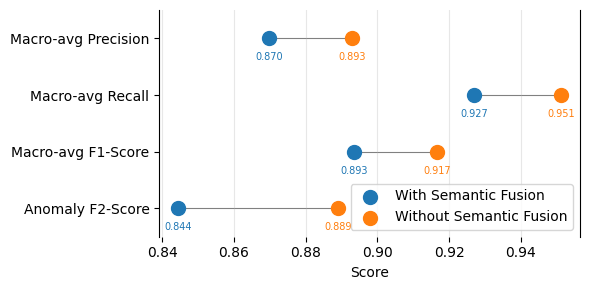

In [ ]:
import numpy as np

# Cleveland dot plot: metrics on y, score on x; one colored dot per evaluation
import matplotlib.pyplot as plt

plot_df = comparison_df.copy()
plot_df["evaluation"] = plot_df["rm_semantic_fusion"].map({False: "With Semantic Fusion", True: "Without Semantic Fusion"})
evals = plot_df["evaluation"].tolist()
metric_cols = [
    "precision_macro_mean",
    "recall_macro_mean",
    "f1_macro_mean",
    "f2_anomaly_mean"
]
y = np.arange(len(metric_cols))
labels = [
    "Macro-avg Precision",
    "Macro-avg Recall",
    "Macro-avg F1-Score",
    "Anomaly F2-Score"
]

fig, ax = plt.subplots(figsize=(6, 3))

# map evaluations to distinct colors
unique_evals = plot_df["evaluation"].unique().tolist()
cmap = plt.get_cmap("tab10")
color_map = {ev: cmap(i) for i, ev in enumerate(unique_evals)}

# draw grey connector lines for each metric
for i in range(len(metric_cols)):
    vals = plot_df[metric_cols].iloc[:, i] if False else plot_df[metric_cols].iloc[:, i]  # noop for clarity
for i in range(len(metric_cols)):
    # values for this metric across evaluations (respect row order)
    vals = plot_df[metric_cols].iloc[:, i].to_numpy()  # not used; keep loop for connector below

# connector and points (use the row order in plot_df)
for i, metric in enumerate(metric_cols):
    vals = plot_df[metric].to_numpy(dtype=float)
    ax.plot(vals, [i, i], color="gray", linewidth=0.8, zorder=1)
for j, ev_name in enumerate(evals):
    row = plot_df.loc[plot_df["evaluation"] == ev_name, metric_cols].iloc[0]
    for i, metric in enumerate(metric_cols):
        ax.annotate(
            f"{row[metric]:.3f}",
            (row[metric], i),
            textcoords="offset points",
            xytext=(0, 14) if j == 0 and abs(plot_df[metric].iloc[0] - plot_df[metric].iloc[1]) < 0.004 else (0, -10),
            ha="center",
            va="top",
            fontsize=7,
            color=color_map[ev_name],
        )
    vals = plot_df.loc[plot_df["evaluation"] == ev_name, metric_cols].iloc[0].to_numpy(dtype=float)
    ax.scatter(vals, y, s=100, color=color_map[ev_name], label=ev_name, zorder=2)

ax.set_yticks(y)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_ylim(y.min() - 0.5, y.max() + 0.5)

ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("Score")
ax.grid(axis="x", alpha=0.3)
# set x limits with a small margin
all_vals = plot_df[metric_cols].to_numpy(dtype=float)
xmin, xmax = all_vals.min(), all_vals.max()
pad = (xmax - xmin) * 0.05 if xmax > xmin else 0.01
ax.set_xlim(xmin - pad, xmax + pad)
ax.legend(loc="lower right")
plt.tight_layout()

plt.show()

In [28]:
trimmed_df = comparison_df[[
    "rm_semantic_fusion",
    "accuracy_mean",
    "accuracy_std",
    "precision_normal_mean",
    "precision_normal_std",
    "recall_normal_mean",
    "recall_normal_std",
    "f1_normal_mean",
    "f1_normal_std",
    "precision_anomaly_mean",
    "precision_anomaly_std",
    "recall_anomaly_mean",
    "recall_anomaly_std",
    "f1_anomaly_mean",
    "f1_anomaly_std",
    "f2_anomaly_mean",
    "f2_anomaly_std",
    "pr_auc_mean",
    "pr_auc_std",
    "fold_time_mean",
    "fold_time_std",
]]
trimmed_df

,rm_semantic_fusion,accuracy_mean,accuracy_std,precision_normal_mean,precision_normal_std,recall_normal_mean,recall_normal_std,f1_normal_mean,f1_normal_std,precision_anomaly_mean,...,recall_anomaly_mean,recall_anomaly_std,f1_anomaly_mean,f1_anomaly_std,f2_anomaly_mean,f2_anomaly_std,pr_auc_mean,pr_auc_std,fold_time_mean,fold_time_std
0,False,0.970053,0.009918,0.990743,0.0068,0.977011,0.010281,0.983781,0.005417,0.748921,...,0.876923,9.230769e-02,0.803206,0.063269,0.844475,0.074015,0.856095,0.052983,326.478,31.669474
1,True,0.975401,0.015350,0.994164,0.0001,0.979310,0.016497,0.986611,0.008501,0.791758,...,0.923077,1.110223e-16,0.846865,0.076926,0.889106,0.036091,0.826287,0.071459,177.244,57.045600


In [29]:
PCT_SCALE_EXCLUDE = {"fold_time"}  # keep seconds as seconds, not *100

def format_stat(mean, std, base):
    scale = 1 if base in PCT_SCALE_EXCLUDE else 100
    return f"{mean * scale:.2f} \u00b1 {std * scale:05.2f}"

metric_bases = [c[:-5] for c in trimmed_df.columns if c.endswith("_mean")]

display_df = pd.DataFrame(index=trimmed_df.index)
for base in metric_bases:
    display_df[base] = trimmed_df.apply(
        lambda row: format_stat(row[f"{base}_mean"], row[f"{base}_std"], base), axis=1
    )

display_df.insert(0, "Semantic Fusion", (trimmed_df["rm_semantic_fusion"].map({False: "Included", True: "Not Included"})))
display_df = display_df.set_index("Semantic Fusion")

final_table = display_df.T
final_table

Semantic Fusion,Included,Not Included
accuracy,97.01 ± 00.99,97.54 ± 01.54
precision_normal,99.07 ± 00.68,99.42 ± 00.01
recall_normal,97.70 ± 01.03,97.93 ± 01.65
f1_normal,98.38 ± 00.54,98.66 ± 00.85
precision_anomaly,74.89 ± 07.74,79.18 ± 12.34
recall_anomaly,87.69 ± 09.23,92.31 ± 00.00
f1_anomaly,80.32 ± 06.33,84.69 ± 07.69
f2_anomaly,84.45 ± 07.40,88.91 ± 03.61
pr_auc,85.61 ± 05.30,82.63 ± 07.15
fold_time,326.48 ± 31.67,177.24 ± 57.05


In [30]:
# Turn the unicode ± into LaTeX math syntax, and escape underscores in row labels
import re

METRIC_LABELS = {
    "Semantic Fusion": "Semantic Fusion",
    "accuracy": "Accuracy (\\%)",
    "precision_normal": "Precision (Normal) (\\%)",
    "recall_normal": "Recall (Normal) (\\%)",
    "f1_normal": "F1 (Normal) (\\%)",
    "precision_anomaly": "Precision (Anomaly) (\\%)",
    "recall_anomaly": "Recall (Anomaly) (\\%)",
    "f1_anomaly": "F1 (Anomaly) (\\%)",
    "f2_anomaly": "F2 (Anomaly) (\\%)",
    "pr_auc": "PR-AUC (\\%)",
    "fold_time": "Fold Training Time (sec/fold)",
}

def to_math_pm(s: str) -> str:
    return re.sub(r"(-?[\d.]+) \u00b1 (-?[\d.]+)", r"$\1 \\pm \2$", s)

latex_ready = final_table.map(to_math_pm)
latex_ready = latex_ready.rename(index=METRIC_LABELS)
latex_ready.index = latex_ready.index.str.replace("_", r"\_", regex=False)

latex_str = latex_ready.to_latex(
    escape=False,  # cell values already contain LaTeX ($\pm$), don't double-escape
    column_format="l" + "c" * len(latex_ready.columns),
    caption="Effect of the DME threshold on test-set performance",
    label="tab:ablation_semantic_fusion",
)
print(latex_str)


\begin{table}
\caption{Effect of the DME threshold on test-set performance}
\label{tab:ablation_semantic_fusion}
\begin{tabular}{lcc}
\toprule
Semantic Fusion & Included & Not Included \\
\midrule
Accuracy (\%) & $97.01 \pm 00.99$ & $97.54 \pm 01.54$ \\
Precision (Normal) (\%) & $99.07 \pm 00.68$ & $99.42 \pm 00.01$ \\
Recall (Normal) (\%) & $97.70 \pm 01.03$ & $97.93 \pm 01.65$ \\
F1 (Normal) (\%) & $98.38 \pm 00.54$ & $98.66 \pm 00.85$ \\
Precision (Anomaly) (\%) & $74.89 \pm 07.74$ & $79.18 \pm 12.34$ \\
Recall (Anomaly) (\%) & $87.69 \pm 09.23$ & $92.31 \pm 00.00$ \\
F1 (Anomaly) (\%) & $80.32 \pm 06.33$ & $84.69 \pm 07.69$ \\
F2 (Anomaly) (\%) & $84.45 \pm 07.40$ & $88.91 \pm 03.61$ \\
PR-AUC (\%) & $85.61 \pm 05.30$ & $82.63 \pm 07.15$ \\
Fold Training Time (sec/fold) & $326.48 \pm 31.67$ & $177.24 \pm 57.05$ \\
\bottomrule
\end{tabular}
\end{table}

